# 1. Augmented Reality Virtual Try-on Survey Data Analysis

In [167]:
#print(sklearn.__version__)

In [168]:
#!pip freeze > requirements.txt

In [ ]:
1.  Dissertation - AR VTO-Latest Version 09172024 Cleaned Dataset-Copy1
2.  Dissertation - AR VTO-Latest Version 09172024-Data Exploration-Copy1
3.  Dissertation - AR VTO-Latest Version 09172024- Create PCA Feature List
4.  Dissertation - AR VTO-Latest Version 09172024-BuildTestHarnesses-with extra models
5.  Dissertation - AR VTO-Latest Version TAM
6.  Dissertation - AR VTO-Latest Version Gradient Boost
7.  Dissertation - AR VTO-Latest Version KNN 
8.  Dissertation - AR VTO-Latest Version Lasso
9.  Dissertation - AR VTO-Latest Version MLP
10. Dissertation - AR VTO-Latest Version MLR
11. Dissertation - AR VTO-Latest Version RF
12. Dissertation - AR VTO-Latest Version Ridge
13. Dissertation - AR VTO-Latest Version SVR
13. Dissertation - AR VTO-Latest Version XGBoost
14. Dissertation - AR VTO - Stats Model MLR
15. Dissertation - AR VTO-Latest Version Final Model


In [ ]:
This notebook 
Input
    df_survey
Output
    df_survey_cleaned

Functions
1. Acquires Data
2. Translates from Vietnamese to English colTrnumn heading
3. Translates gender, age, values
4. Translates usage types from Vietnamese to English
5. Feature Engineering 
    age
    gender
    interaction features
    quadratic features

##  Research Questions

In [1]:
import pandas as pd
import numpy as np
from numpy import arange
import scipy.stats as stats
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
#from pdpbox import pdp, get_dataset, info_plots
from sklearn.metrics import mutual_info_score
from sklearn import metrics
#import eli5
#from eli5.sklearn import PermutationImportance

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mutual_info_score
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
 
# Models
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.cluster import KMeans

# Feature Selection and Dimensionality Reduction
from sklearn.decomposition import PCA
#from eli5.sklearn import PermutationImportance

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from factor_analyzer import FactorAnalyzer
import semopy
from semopy import Model, Optimizer, calc_stats

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from pandas.plotting import scatter_matrix

#Model Interpretation
#import eli5

# Language Translation
from googletrans import Translator
translator = Translator()
from translate import Translator

translator = Translator(to_lang="en", from_lang="vi")
translation_1 = translator.translate("nữ")
translation_0 = translator.translate("nam")

print(f"Translation of 'nữ': {translation_1}")
print(f"Translation of 'nam': {translation_0}")

# Miscellaneous
# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

Translation of 'nữ': female
Translation of 'nam': male


## Data Understanding

### Data Acquisition

In [2]:
#read csv file

df_survey = pd.read_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\3. AR_fashion_Originaldata_23.11Vietnamese.csv')

In [3]:
#display column headers and the first row

df_survey.head(2)

,Timestamp,"Các bạn vui lòng chọn mức độ đồng ý của mình với mỗi câu nhận định sau đây (1 - rất không đồng ý, 5 - rất đồng ý): [Tôi biết rõ về AR]",I. Độ quen thuộc với công nghệ và ứng dụng AR [1. Tôi quen thuộc với những công nghệ này],I. Độ quen thuộc với công nghệ và ứng dụng AR [2. Tôi đang sử dụng những công nghệ này trong cuộc sống hàng ngày],II. Sử dụng trong các lĩnh vực của cuộc sống (có thể chọn nhiều đáp án),III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [1. Môi trường mua sắm ảo],III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [2. Chuyến tham quan ảo],"III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [3. Hình dung, mô hình]",III. Mức độ quen thuộc với các ứng dụng AR và phương pháp mua sắm khi sử dụng AR (các ứng dụng của AR được sử dụng trong mua sắm) [4. Giả lập],I. Sự thích thú [1. Tôi nhận thấy mua hàng thời trang thông qua các ứng dụng thực tế ảo tăng cường thú vị.],I. Sự thích thú [2. Tôi nhận thấy quá trình mua hàng thông qua các ứng dụng thực tế ảo tăng cường khiến tôi hài lòng],I. Sự thích thú [3. Tôi cảm thấy vui vẻ khi sử dụng các ứng dụng thực tế ảo tăng cường trong quá trình mua hàng.],I. Sự thích thú [4. Tôi nhận thấy mua hàng thời trang thông qua các ứng dụng thực tế ảo tăng cường hấp dẫn.],II. Bản sắc xã hội [1. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang khiến tôi cảm thấy bản thân được cảm nhận.],II. Bản sắc xã hội [2. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang giúp cải thiện cách tôi nhận được khi mua hàng.],II. Bản sắc xã hội [3. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang tạo ấn tượng tốt với người khác.],II. Bản sắc xã hội [4. Vai trò của tôi trong xã hội đòi hỏi phải sử dụng thực tế ảo tăng cường trong mua sắm thời trang.],III. Bản sắc cá nhân [1. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang giúp tôi đạt được hình mẫu mà tôi hướng đến.],III. Bản sắc cá nhân [2. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang giúp chúng ta giảm khoảng cách giữa giữa con người hiện tại của tôi và hình mẫu mà tôi mong muốn trở thành],III. Bản sắc cá nhân [3. Sử dụng thực tế ảo tăng cường trong mua sắm thời trang là một phần hình mẫu của tôi.],IV. Dễ sử dụng [1. Tôi nghĩ rằng việc sử dụng ứng dụng thực tế ảo tăng cường rất dễ dàng],IV. Dễ sử dụng [2. Tôi nghĩ rất đơn giản để học cách sử dụng ứng dụng thực tế ảo tăng cường.],IV. Dễ sử dụng [3. Tôi nghĩ rằng nó không đòi hỏi nhiều nỗ lực để sử dụng một ứng dụng thực tế ảo tăng cường.],IV. Dễ sử dụng [4. Tôi nghĩ rằng ứng dụng thực tế ảo tăng cường là rất rõ ràng và dễ hiểu.],V. Lợi ích [1. Tôi có thể cải thiện quy trình mua hàng thời trang với một ứng dụng thực tế ảo tăng cường.],V. Lợi ích [2. Quá trình mua hàng thời trang của tôi sẽ hiệu quả hơn khi áp dụng ứng dụng thực tế ảo tăng cường],V. Lợi ích [3. Thực tế ảo tăng cường sẽ hữu ích khi mua hàng thời trang],V. Lợi ích [4. Thực tế ảo tăng cường sẽ cải thiện khả năng của tôi khi mua hàng trực tuyến.],VI. Thái độ [1. Tôi thích ý tưởng mua hàng thời trang với thực tế ảo tăng cường.],VI. Thái độ [2. Tôi nghĩ rằng đó là một ý kiến hay khi mua hàng thời trang với thực tế ảo tăng cường.],VI. Thái độ [3. Tôi có một cái nhìn thích thú với việc mua hàng thời trang với thực tế ảo tăng cường],VII. Giá trị [1. Ứng dụng thực tế ảo tăng cường có thể mang lại lợi ích cho tôi nhiều hơn so với mức cần.],VII. Giá trị [2. Các ứng dụng thực tế ảo tăng cường phải xứng đáng đối với tôi so với sự yêu cầu được nhận lại.],"VII. Giá trị [3. Nhìn chung, các ứng dụng thực tế ảo tăng cường đều mang giá trị tốt.]",VIII. Sự vui vẻ [1. Sử dụng các ứng dụng thực tế ảo tăng cường trong mua sắm thời trang rất vui.],VIII. Sự vui vẻ [2. Sử dụng các ứng dụng thực tế ảo tăng cường trong mua sắm thời trang rất hứng thú .],VIII. Sự vui vẻ [3. Sử dụng các ứng d

In [4]:
#Get Size of dataset
df_survey.shape



(523, 44)

In [5]:
### # Translate column names

In [6]:

# Create a list of new column names
new_cols = ['Timestamp', 'AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday','use_in_all_aspects','Virtual_shopping_environment','Virtual_tour','Visualize_model','Emulation','PE1','PE2','PE3','PE4','SOI1','SOI2','SOI3','SOI4','SEI1','SEI2','SEI3','PEOU1','PEOU2','PEOU3','PU1','PU2','PU3','PU4','B1','AT1','AT2','AT3','PPV1','PPV2','PPV3','HM1','HM2','HM3','BI1','BI2','BI3','BI4','Gender','AGE','Location'] 

# Rename columns using the list
df_survey.columns = new_cols

In [7]:
# Save file to disk
df_survey.to_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\Archived_Survey_data.csv')

In [8]:
#Get data type and number of null values for each feature
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1 

In [9]:
df_survey.shape

(523, 44)

In [10]:
# check for missing values
df_survey.isna().sum().sum()

4356

In [11]:
#remove rows woth all null values
df_survey_cleaned = df_survey.dropna(how='all')

In [12]:
#check for rows with all null values after removing them

df_survey_cleaned.isna().sum().sum()


0

In [13]:
#check each column for null values

df_survey_cleaned.isna().sum()


Timestamp                       0
AR_Knowledgeable                0
familiar_with_technology        0
use_AR_everyday                 0
use_in_all_aspects              0
Virtual_shopping_environment    0
Virtual_tour                    0
Visualize_model                 0
Emulation                       0
PE1                             0
PE2                             0
PE3                             0
PE4                             0
SOI1                            0
SOI2                            0
SOI3                            0
SOI4                            0
SEI1                            0
SEI2                            0
SEI3                            0
PEOU1                           0
PEOU2                           0
PEOU3                           0
PU1                             0
PU2                             0
PU3                             0
PU4                             0
B1                              0
AT1                             0
AT2           

In [14]:
# check for number of rows and left after removing null rows

df_survey_cleaned.shape

(424, 44)

In [15]:
# get all numeric columns
df_numerics_only = df_survey_cleaned.select_dtypes(include='number').columns
 
print(df_numerics_only)

Index(['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday',
       'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model',
       'Emulation', 'PE1', 'PE2', 'PE3', 'PE4', 'SOI1', 'SOI2', 'SOI3', 'SOI4',
       'SEI1', 'SEI2', 'SEI3', 'PEOU1', 'PEOU2', 'PEOU3', 'PU1', 'PU2', 'PU3',
       'PU4', 'B1', 'AT1', 'AT2', 'AT3', 'PPV1', 'PPV2', 'PPV3', 'HM1', 'HM2',
       'HM3', 'BI1', 'BI2', 'BI3', 'BI4'],
      dtype='object')


In [16]:
## validate survey response contain 1 thru 5
def check_columns(df):
    columns_to_check = df_numerics_only
    column_number = 0
    for column in columns_to_check:
        column_number = column_number + 1
        #print (f"Column contains valid 1 thru 5: {column_number}")
        if not df[column].isin(range(1, 6)).all():
            print (df[column])
            print(f"Column does not contain valid 1 thru 5: {column}")
            return False
    return True

# Call the function with df_survey
result = check_columns(df_survey_cleaned)
print(f"All specified columns contain only values 1 through 5: {result}")

All specified columns contain only values 1 through 5: True


In [17]:
# check the values in the gender column
df_survey_cleaned['Gender'].value_counts()

Gender
nữ     295
nam    129
Name: count, dtype: int64

In [18]:
# check the values in the AGE column
df_survey_cleaned['AGE'].value_counts()

AGE
Trên 40 tuổi      180
20 đến 29 tuổi    138
30 đến 39 tuổi     97
Dưới 19 tuổi        8
23 đến 30 tuổi      1
Name: count, dtype: int64

In [19]:
from googletrans import Translator
translator = Translator()
translation_1 = translator.translate('nữ', src='vi', dest='en')
translation_0 = translator.translate('nam', src='vi', dest='en')


In [20]:
print(translation_0.text)
print(translation_1.text)

male
female


In [21]:
# Translate Vietnames gender values to English Male and female values

df_survey_cleaned.loc[:, 'Gender_eng'] = df_survey_cleaned['Gender'].replace({'nam': 'male', 'nữ': 'female'}).values

C:\Users\cemcd\AppData\Local\Temp\ipykernel_20568\702946529.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'Gender_eng'] = df_survey_cleaned['Gender'].replace({'nam': 'male', 'nữ': 'female'}).values


In [22]:
# display new feature to check translations

df_survey_cleaned['Gender_eng']

0        male
1      female
2        male
3        male
4        male
        ...  
419    female
420    female
421    female
422    female
522      male
Name: Gender_eng, Length: 424, dtype: object

In [23]:
# creature new feature for document (can be removedO

df_survey_cleaned.loc[:, 'Gender_vietnamese'] = df_survey_cleaned['Gender'].values

C:\Users\cemcd\AppData\Local\Temp\ipykernel_20568\124834956.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'Gender_vietnamese'] = df_survey_cleaned['Gender'].values


In [24]:
df_survey_cleaned[['Gender_vietnamese','Gender_eng']].head()

,Gender_vietnamese,Gender_eng
0,nam,male
1,nữ,female
2,nam,male
3,nam,male
4,nam,male


In [25]:
# check the values in the gender column
df_survey_cleaned['Gender'].value_counts()

Gender
nữ     295
nam    129
Name: count, dtype: int64

In [26]:
# encode gender values to 0 and 1. 0 - male , 1 - female
df_survey_cleaned.loc[:, 'Gender_num'] = df_survey_cleaned['Gender_eng'].replace({'male': 0, 'female': 1})

C:\Users\cemcd\AppData\Local\Temp\ipykernel_20568\3959655781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survey_cleaned.loc[:, 'Gender_num'] = df_survey_cleaned['Gender_eng'].replace({'male': 0, 'female': 1})


In [27]:
df_survey_cleaned['Gender_num'].value_counts()

Gender_num
1    295
0    129
Name: count, dtype: int64

In [28]:
## Translate Age

In [29]:
df_survey['AGE'].unique()

array(['Trên 40 tuổi', '20 đến 29 tuổi', '30 đến 39 tuổi', 'Dưới 19 tuổi',
       nan, '23 đến 30 tuổi'], dtype=object)

In [30]:
# create df containing only unique age cohort values
age_cohorts=[]
age_cohorts = df_survey[['AGE']].drop_duplicates()
age_cohorts



,AGE
0,Trên 40 tuổi
1,20 đến 29 tuổi
7,30 đến 39 tuổi
34,Dưới 19 tuổi
423,NaN
522,23 đến 30 tuổi


In [31]:
import googletrans
from googletrans import Translator

translator = Translator()

def translate_text(text, target_language):
    try:
        translation = translator.translate(text, dest=target_language)
        return translation.text
    except Exception as e:
        print(f"Error translating '{text}': {e}")
        return text

In [32]:
# Translate 'Age Column Values
age_cohorts['AGE_eng'] = age_cohorts['AGE'].apply(lambda x: translate_text(x, 'en') if pd.notnull(x) else x)

In [33]:
age_cohorts

,AGE,AGE_eng
0,Trên 40 tuổi,Over 40 years old
1,20 đến 29 tuổi,20 to 29 years old
7,30 đến 39 tuổi,30 to 39 years old
34,Dưới 19 tuổi,Under 19 years old
423,NaN,NaN
522,23 đến 30 tuổi,23 to 30 years old


In [34]:
 # create age cohort dictionary
age_cohorts_dict = []
# Convert DataFrame to dictionary
age_cohorts_dict = age_cohorts.set_index('AGE')['AGE_eng'].to_dict()



In [35]:
age_cohorts_dict

{'Trên 40 tuổi': 'Over 40 years old',
 '20 đến 29 tuổi': '20 to 29 years old',
 '30 đến 39 tuổi': '30 to 39 years old',
 'Dưới 19 tuổi': 'Under 19 years old',
 nan: nan,
 '23 đến 30 tuổi': '23 to 30 years old'}

In [36]:
# Now  use the dictionary with the map function
 
df_survey_cleaned = df_survey_cleaned.copy()

df_survey_cleaned.loc[:, 'AGE_eng'] = df_survey_cleaned['AGE'].map(age_cohorts_dict)

In [37]:
# display vietnamese and english AGE translations
df_survey_cleaned[['AGE','AGE_eng']].head(1)

,AGE,AGE_eng
0,Trên 40 tuổi,Over 40 years old


In [38]:
# check the counts for AGE 

df_survey_cleaned[['AGE','AGE_eng']].value_counts()

AGE             AGE_eng           
Trên 40 tuổi    Over 40 years old     180
20 đến 29 tuổi  20 to 29 years old    138
30 đến 39 tuổi  30 to 39 years old     97
Dưới 19 tuổi    Under 19 years old      8
23 đến 30 tuổi  23 to 30 years old      1
Name: count, dtype: int64

In [39]:
df_survey_cleaned[['AGE_eng']].value_counts()

AGE_eng           
Over 40 years old     180
20 to 29 years old    138
30 to 39 years old     97
Under 19 years old      8
23 to 30 years old      1
Name: count, dtype: int64

In [40]:
# Update AGE_eng column
df_survey_cleaned.loc[df_survey_cleaned['AGE_eng'] == '23 to 30 years old', 'AGE_eng'] = '20 to 29 years old'

# Update AGE column
df_survey_cleaned.loc[df_survey_cleaned['AGE_eng'] == '20 to 29 years old', 'AGE'] = '20 đến 29 tuổi'

# Verify the changes
print(df_survey_cleaned['AGE_eng'].value_counts())
print(df_survey_cleaned['AGE'].value_counts())
 

AGE_eng
Over 40 years old     180
20 to 29 years old    139
30 to 39 years old     97
Under 19 years old      8
Name: count, dtype: int64
AGE
Trên 40 tuổi      180
20 đến 29 tuổi    139
30 đến 39 tuổi     97
Dưới 19 tuổi        8
Name: count, dtype: int64


In [41]:
# check the counts for AGE 

df_survey_cleaned[['AGE','AGE_eng']].value_counts()

AGE             AGE_eng           
Trên 40 tuổi    Over 40 years old     180
20 đến 29 tuổi  20 to 29 years old    139
30 đến 39 tuổi  30 to 39 years old     97
Dưới 19 tuổi    Under 19 years old      8
Name: count, dtype: int64

In [42]:
# encode age values to 0 , 1 , 2,  3
df_survey_cleaned.loc[:, 'AGE_num'] = df_survey_cleaned['AGE_eng'].replace({'Under 19 years old': 0,'23 to 30 years old':1 ,'20 to 29 years old': 1, '30 to 39 years old':'2', 'Over 40 years old':'3'})

In [43]:
#check encoded AGE counts
df_survey_cleaned['AGE_num'].value_counts()

AGE_num
3    180
1    139
2     97
0      8
Name: count, dtype: int64

In [44]:
df_survey_cleaned.head(1)

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3


In [45]:
# create explicit age vietnamese column for document purposes 
df_survey_cleaned['Age_vietnamese'] = df_survey_cleaned['AGE']

In [46]:
# display 
df_survey_cleaned[['Age_vietnamese','AGE_eng','AGE_num','Gender_vietnamese','Gender_eng','Gender_num']].head()

,Age_vietnamese,AGE_eng,AGE_num,Gender_vietnamese,Gender_eng,Gender_num
0,Trên 40 tuổi,Over 40 years old,3,nam,male,0
1,20 đến 29 tuổi,20 to 29 years old,1,nữ,female,1
2,Trên 40 tuổi,Over 40 years old,3,nam,male,0
3,20 đến 29 tuổi,20 to 29 years old,1,nam,male,0
4,20 đến 29 tuổi,20 to 29 years old,1,nam,male,0


In [47]:
df_survey_cleaned['AGE_num'].value_counts()

AGE_num
3    180
1    139
2     97
0      8
Name: count, dtype: int64

In [48]:
# look at  gender distribution by age cohort
df_survey_cleaned.groupby('AGE_eng')['Gender'].value_counts()

AGE_eng             Gender
20 to 29 years old  nữ         75
                    nam        64
30 to 39 years old  nam        51
                    nữ         46
Over 40 years old   nữ        169
                    nam        11
Under 19 years old  nữ          5
                    nam         3
Name: count, dtype: int64

In [49]:
#df_survey_cleaned['AGE','AGE_eng','Gender','']

In [50]:

# Function to separate 'use_in_all_aspects into separate columns' - Usage_1, Usage_2, Usage_3, Usage_4, Usage_5, Usage_6, Usage_7
def split_values(value):
    values = []
    for val in value.split(','):
        values.extend(val.split('/'))
    return pd.Series(values)

# Split the 'Values' column and create new columns
split_df = df_survey_cleaned['use_in_all_aspects'].apply(split_values).apply(pd.Series, 1).fillna('')
new_columns = [f'Usage_{i+1}' for i in range(split_df.shape[1])]
split_df.columns = new_columns

# Concatenate the original DataFrame with the split columns
result = pd.concat([df_survey_cleaned, split_df], axis=1)
result.head()
 

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,,,,,
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,nữ,20 đến 29 tuổi,miền Bắc,female,nữ,1,20 to 29 years old,1,20 đến 29 tuổi,Mua sắm,,,,,,
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Học tập,giáo dục,,,,,
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,4.0,5.0,5.0,3.0,5.0,4.0,3.0,3.0,2.0,2.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Mua sắm thời trang,,,,,
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,


In [51]:
 result['Usage_1'].head()

0    Du lịch ảo 
1        Mua sắm
2        Học tập
3       Giải trí
4       Giải trí
Name: Usage_1, dtype: object

In [52]:
ar_usage_types1 =[]
ar_usage_types1 = result[['Usage_1']].drop_duplicates().rename(columns={'Usage_1': 'usage_type'})
ar_usage_types1


,usage_type
0,Du lịch ảo
1,Mua sắm
2,Học tập
3,Giải trí
17,Khác
64,Mua sắm thời trang


In [53]:
ar_usage_types2 =[]
ar_usage_types2 = result[['Usage_2']].drop_duplicates().rename(columns={'Usage_2': 'usage_type'})
ar_usage_types2


,usage_type
0,trải nghiệm
1,
2,giáo dục
3,Mua sắm thời trang
4,Du lịch ảo
18,Học tập
72,Khác


In [54]:
ar_usage_types3 =[]
ar_usage_types3 = result[['Usage_3']].drop_duplicates().rename(columns={'Usage_3': 'usage_type'})
ar_usage_types3


,usage_type
0,
4,trải nghiệm
10,Mua sắm thời trang
18,giáo dục
30,Học tập
38,Khác


In [55]:
ar_usage_types4 =[]
ar_usage_types4 = result[['Usage_4']].drop_duplicates().rename(columns={'Usage_4': 'usage_type'})
ar_usage_types4


,usage_type
0,
4,Học tập
12,Mua sắm thời trang
30,giáo dục
56,Khác


In [56]:
ar_usage_types5 =[]
ar_usage_types5 = result[['Usage_5']].drop_duplicates().rename(columns={'Usage_5': 'usage_type'})
ar_usage_types5


,usage_type
0,
4,giáo dục
14,Khác
96,Mua sắm thời trang


In [57]:
ar_usage_types6 =[]
ar_usage_types6 = result[['Usage_6']].drop_duplicates().rename(columns={'Usage_6': 'usage_type'})
ar_usage_types6


,usage_type
0,
4,Mua sắm thời trang
326,Khác


In [58]:
ar_usage_types7 =[]
ar_usage_types7 = result[['Usage_7']].drop_duplicates().rename(columns={'Usage_7': 'usage_type'})
ar_usage_types7


,usage_type
0,
51,Khác


In [59]:
# Concatenate Usage_1 thru 7 into one dataframe

df_usage_types = pd.concat([ar_usage_types1,ar_usage_types2,ar_usage_types3,ar_usage_types4,ar_usage_types5,ar_usage_types6,ar_usage_types7], ignore_index=True)
 
df_usage_types.head(1)

,usage_type
0,Du lịch ảo


In [60]:
df_usage_types['usage_type'].value_counts()

usage_type
                       6
 Khác                  6
 Mua sắm thời trang    5
 giáo dục              4
 Học tập               3
 trải nghiệm           2
Du lịch ảo             1
Mua sắm                1
Học tập                1
Giải trí               1
Khác                   1
Mua sắm thời trang     1
 Du lịch ảo            1
Name: count, dtype: int64

In [61]:
#create usage type dictionary to map vietnamese translation to English translation

usage_types_dict = {
'Khác': 'Other',
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}

In [62]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424 entries, 0 to 522
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     424 non-null    object 
 1   AR_Knowledgeable              424 non-null    float64
 2   familiar_with_technology      424 non-null    float64
 3   use_AR_everyday               424 non-null    float64
 4   use_in_all_aspects            424 non-null    object 
 5   Virtual_shopping_environment  424 non-null    float64
 6   Virtual_tour                  424 non-null    float64
 7   Visualize_model               424 non-null    float64
 8   Emulation                     424 non-null    float64
 9   PE1                           424 non-null    float64
 10  PE2                           424 non-null    float64
 11  PE3                           424 non-null    float64
 12  PE4                           424 non-null    float64
 13  SOI1      

In [63]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_1'] = result['Usage_1'].str.lstrip()

result.loc[:, 'Usage_1_en'] = result['Usage_1'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
})

In [64]:
result['Usage_1_en'].value_counts()

Usage_1_en
Entertainment       309
Du lịch ảo           51
Other                29
Study                23
Fashion shopping     11
Shopping              1
Name: count, dtype: int64

In [65]:
result['Usage_2'].value_counts()

Usage_2
 Du lịch ảo            175
                       127
 trải nghiệm            51
 Học tập                33
 giáo dục               23
 Mua sắm thời trang      8
 Khác                    7
Name: count, dtype: int64

In [66]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_2'] = result['Usage_2'].str.lstrip()


result.loc[:, 'Usage_2_en'] = result['Usage_2'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
})

In [67]:
result['Usage_2_en'].value_counts()

Usage_2_en
Du lịch ảo          175
                    127
experience           51
Study                33
education            23
Fashion shopping      8
Other                 7
Name: count, dtype: int64

In [68]:
result['Usage_3'].value_counts()

Usage_3
                       188
 trải nghiệm           175
 giáo dục               33
 Học tập                18
 Mua sắm thời trang      7
 Khác                    3
Name: count, dtype: int64

In [69]:
# Use the dictionary with the map function to add English version of the usage type
result['Usage_3'] = result['Usage_3'].str.lstrip()


result.loc[:, 'Usage_3_en'] = result['Usage_3'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [70]:
result['Usage_3_en'].value_counts()

Usage_3_en
                    188
experience          175
education            33
Study                18
Fashion shopping      7
Other                 3
Name: count, dtype: int64

In [71]:
result['Usage_4'].value_counts()

Usage_4
                       260
 Học tập               115
 Mua sắm thời trang     28
 giáo dục               18
 Khác                    3
Name: count, dtype: int64

In [72]:
result['Usage_4'] = result['Usage_4'].str.lstrip()


result.loc[:, 'Usage_4_en'] = result['Usage_4'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [73]:
result['Usage_4_en'].value_counts()

Usage_4_en
                    260
Study               115
Fashion shopping     28
education            18
Other                 3
Name: count, dtype: int64

In [74]:
result['Usage_5'].value_counts()

Usage_5
                       302
 giáo dục              115
 Mua sắm thời trang      5
 Khác                    2
Name: count, dtype: int64

In [75]:
result['Usage_5'] = result['Usage_5'].str.lstrip()


result.loc[:, 'Usage_5_en'] = result['Usage_5'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [76]:
result['Usage_5_en'].value_counts()

Usage_5_en
                    302
education           115
Fashion shopping      5
Other                 2
Name: count, dtype: int64

In [77]:
result['Usage_6'].value_counts()

Usage_6
                       349
 Mua sắm thời trang     67
 Khác                    8
Name: count, dtype: int64

In [78]:
result['Usage_6'] = result['Usage_6'].str.lstrip()


result.loc[:, 'Usage_6_en'] = result['Usage_6'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [79]:
result['Usage_6_en'].value_counts()

Usage_6_en
                    349
Fashion shopping     67
Other                 8
Name: count, dtype: int64

In [80]:
result['Usage_7'].value_counts()

Usage_7
         409
 Khác     15
Name: count, dtype: int64

In [81]:
result['Usage_7'] = result['Usage_7'].str.lstrip()

result.loc[:, 'Usage_7_en'] = result['Usage_7'].replace({'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}) 

In [82]:
result['Usage_7_en'].value_counts()

Usage_7_en
         409
Other     15
Name: count, dtype: int64

In [83]:
df_survey_cleaned = result

In [84]:
df_survey_cleaned[['use_in_all_aspects','Usage_1_en','Usage_2_en','Usage_3_en','Usage_4_en', 'Usage_5_en','Usage_6_en','Usage_7_en']]

,use_in_all_aspects,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en
0,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,
1,Mua sắm,Shopping,,,,,,
2,"Học tập, giáo dục",Study,education,,,,,
3,"Giải trí, Mua sắm thời trang",Entertainment,Fashion shopping,,,,,
4,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,
...,...,...,...,...,...,...,...,...
419,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,Other
420,"Giải trí, Du lịch ảo / trải nghiệm, Mua sắm th...",Entertainment,Du lịch ảo,experience,Fashion shopping,,,
421,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,
422,Du lịch ảo / trải nghiệm,Du lịch ảo,experience,,,,,


In [85]:
import pandas as pd
from collections import Counter

# Placeholder for translations (fill in with actual translations)
translations = {
'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}

# Function to process each group
def process_group(group):
    all_values = ','.join(group['use_in_all_aspects']).replace('|', ',').replace('/', ',')
    value_list = [value.strip() for value in all_values.split(',')]
    value_counts = Counter(value_list)
    return [(value, translations.get(value, 'N/A'), count) for value, count in value_counts.items()]

# Group by Gender and age_cohort and apply the function
grouped_results = df_survey_cleaned.groupby(['Gender_eng', 'AGE_eng']).apply(process_group)

# Print the results
for (gender, age_cohort), values in grouped_results.items():
    print(f"Gender: {gender}, Age Cohort: {age_cohort}")
    for value, translation, count in values:
        print(f"  Value: {value}, Translation: {translation}, Count: {count}")

Gender: female, Age Cohort: 20 to 29 years old
  Value: Mua sắm, Translation: Shopping, Count: 1
  Value: Giải trí, Translation: Entertainment, Count: 53
  Value: Du lịch ảo, Translation: Virtual travel, Count: 44
  Value: trải nghiệm, Translation: experience, Count: 44
  Value: Học tập, Translation: Study, Count: 47
  Value: giáo dục, Translation: education, Count: 47
  Value: Mua sắm thời trang, Translation: Fashion shopping, Count: 39
  Value: Khác, Translation: Other, Count: 8
Gender: female, Age Cohort: 30 to 39 years old
  Value: Giải trí, Translation: Entertainment, Count: 32
  Value: Du lịch ảo, Translation: Virtual travel, Count: 17
  Value: trải nghiệm, Translation: experience, Count: 17
  Value: Học tập, Translation: Study, Count: 13
  Value: giáo dục, Translation: education, Count: 13
  Value: Mua sắm thời trang, Translation: Fashion shopping, Count: 11
  Value: Khác, Translation: Other, Count: 15
Gender: female, Age Cohort: Over 40 years old
  Value: Học tập, Translation: 

grouped results Gender_eng  AGE_eng           
female      20 to 29 years old    [(Shopping, 1), (Entertainment, 53), (Virtual ...
            30 to 39 years old    [(Entertainment, 32), (Virtual travel, 17), (e...
            Over 40 years old     [(Study, 66), (education, 66), (Entertainment,...
            Under 19 years old    [(Entertainment, 3), (Study, 2), (education, 2...
male        20 to 29 years old    [(Entertainment, 53), (Fashion shopping, 25), ...
            30 to 39 years old    [(Entertainment, 38), (Fashion shopping, 17), ...
            Over 40 years old     [(Virtual travel, 5), (experience, 5), (Study,...
            Under 19 years old    [(Other, 2), (Virtual travel, 2), (experience,...
dtype: object


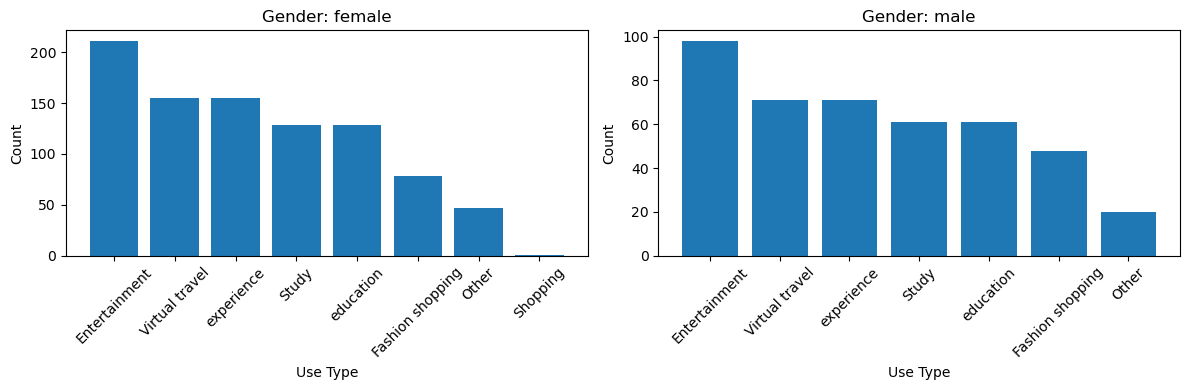

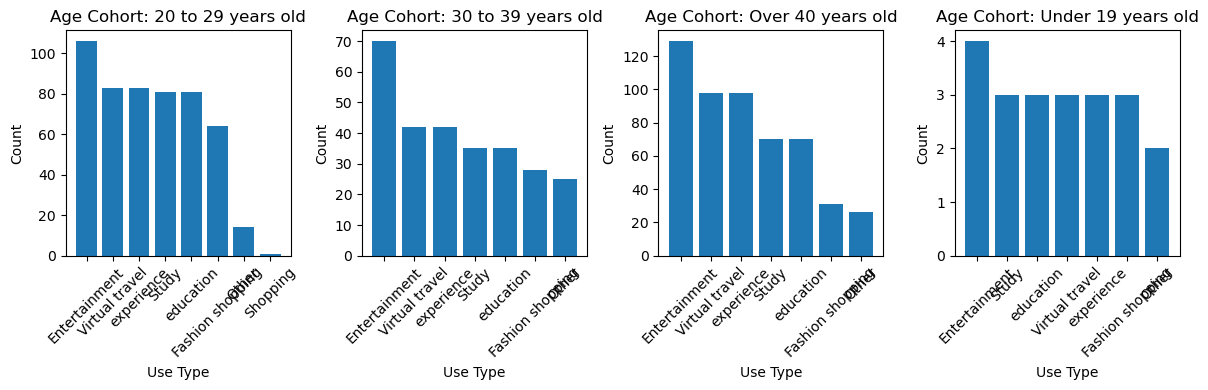

In [86]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt


# Placeholder for translations (fill in with actual translations)
translations = {
'Khác': 'Other', 
'Mua sắm thời trang': 'Fashion shopping',
'giáo dục': 'education',
'Học tập': 'Study',
'trải nghiệm': 'experience',
'Du lịch ảo': 'Virtual travel',
'Giải trí': 'Entertainment',
'Mua sắm': 'Shopping'
}

# Function to process each group
def process_group(group):
    all_values = ','.join(group['use_in_all_aspects']).replace('|', ',').replace('/', ',')
    value_list = [value.strip() for value in all_values.split(',')]
    value_counts = Counter(value_list)
    return [(translations.get(value, 'N/A'), count) for value, count in value_counts.items()]

# Group by Gender and age_cohort and apply the function
grouped_results = df_survey_cleaned.groupby(['Gender_eng', 'AGE_eng']).apply(process_group)
print(f'grouped results {grouped_results}')
# Plotting function
def plot_grouped_results(grouped_results, group_by):
    num_plots = len(grouped_results)
    fig, axes = plt.subplots(1, num_plots, figsize=(12, 4))  # Adjust the figsize as needed

    for ax, (group, values) in zip(axes, grouped_results.items()):
        # Sort values by count
        sorted_values = sorted(values, key=lambda x: x[1], reverse=True)
        labels, counts = zip(*sorted_values)

        # Create bar plot
        ax.bar(labels, counts)
        ax.set_title(f'{group_by}: {group}')
        ax.set_xlabel('Use Type')
        ax.set_ylabel('Count')
        ax.set_xticks(range(len(labels)))  # Set the position of ticks
        ax.set_xticklabels(labels, rotation=45)  # Set the labels with rotation
    
    plt.tight_layout()
    plt.show()

# Plot by Gender
plot_grouped_results(df_survey_cleaned.groupby('Gender_eng').apply(process_group), 'Gender')

# Plot by Age Cohort
plot_grouped_results(df_survey_cleaned.groupby('AGE_eng').apply(process_group), 'Age Cohort')

### Tally up different usage types for each observation

In [87]:
import pandas as pd

# Create a list of columns to check
usage_cols = ['Usage_1', 'Usage_2', 'Usage_3', 'Usage_4', 'Usage_5', 'Usage_6', 'Usage_7']

# Initialize the 'use_type_cnts' column with 0


df_survey_cleaned['use_type_cnts'] = 0

# Iterate over each row in the DataFrame
for idx, row in df_survey_cleaned.iterrows():
    # Check if Usage_1 is not blank or null
    if pd.notnull(row['Usage_1']) and row['Usage_1'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] = 1
    
    # Check if Usage_2 is not blank or null
    if pd.notnull(row['Usage_2']) and row['Usage_2'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_3 is not blank or null
    if pd.notnull(row['Usage_3']) and row['Usage_3'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_4']) and row['Usage_4'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
    
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_5']) and row['Usage_5'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_6']) and row['Usage_6'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
        
    # Check if Usage_4 is not blank or null
    if pd.notnull(row['Usage_7']) and row['Usage_7'] != '':
        df_survey_cleaned.at[idx, 'use_type_cnts'] += 1
    

In [88]:
df_survey_cleaned['use_type_cnts'].value_counts()

use_type_cnts
1    127
3     72
2     61
6     60
5     47
4     42
7     15
Name: count, dtype: int64

In [89]:
df_survey_cleaned['use_type_cnts'].value_counts(normalize=True)

use_type_cnts
1    0.299528
3    0.169811
2    0.143868
6    0.141509
5    0.110849
4    0.099057
7    0.035377
Name: proportion, dtype: float64

In [90]:
df_survey_cleaned[['AGE_eng','use_type_cnts']].value_counts()

AGE_eng             use_type_cnts
Over 40 years old   1                55
30 to 39 years old  1                37
Over 40 years old   3                34
20 to 29 years old  1                32
Over 40 years old   2                32
20 to 29 years old  6                31
                    3                22
Over 40 years old   5                20
20 to 29 years old  5                20
Over 40 years old   6                18
                    4                18
30 to 39 years old  3                15
20 to 29 years old  2                14
30 to 39 years old  2                13
20 to 29 years old  4                13
30 to 39 years old  6                11
                    4                10
                    5                 7
20 to 29 years old  7                 7
30 to 39 years old  7                 4
Over 40 years old   7                 3
Under 19 years old  1                 3
                    2                 2
                    3                 1
      

In [91]:
df_survey_cleaned.groupby(['AGE_eng']).aggregate({'use_type_cnts':'sum'}) 

,use_type_cnts
AGE_eng,
20 to 29 years old,513
30 to 39 years old,277
Over 40 years old,522
Under 19 years old,21


In [92]:
df_survey_cleaned.head()

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,,,,,,Du lịch ảo,experience,,,,,,2
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,nữ,20 đến 29 tuổi,miền Bắc,female,nữ,1,20 to 29 years old,1,20 đến 29 tuổi,Mua sắm,,,,,,,Shopping,,,,,,,1
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Học tập,giáo dục,,,,,,Study,education,,,,,,2
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,4.0,5.0,5.0,3.0,5.0,4.0,3.0,3.0,2.0,2.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Mua sắm thời trang,,,,,,Entertainment,Fashion shopping,,,,,,2
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,,Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,,6


In [93]:
df_survey_cleaned[['Usage_1','Usage_2','Usage_3','Usage_4','Usage_5','Usage_6','Usage_7']]

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7
0,Du lịch ảo,trải nghiệm,,,,,
1,Mua sắm,,,,,,
2,Học tập,giáo dục,,,,,
3,Giải trí,Mua sắm thời trang,,,,,
4,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,
...,...,...,...,...,...,...,...
419,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,Khác
420,Giải trí,Du lịch ảo,trải nghiệm,Mua sắm thời trang,,,
421,Du lịch ảo,trải nghiệm,,,,,
422,Du lịch ảo,trải nghiệm,,,,,


### Feature Engineering

### Create New Features - TAM Construct

In [94]:
df_survey_cleaned['BI'] = (df_survey_cleaned['BI1'] + df_survey_cleaned['BI2'] + df_survey_cleaned['BI3'] + df_survey_cleaned['BI4']) / 4

In [95]:
df_survey_cleaned['PE'] = (df_survey_cleaned['PE1'] + df_survey_cleaned['PE2'] + df_survey_cleaned['PE3'] + df_survey_cleaned['PE4']) / 4

In [96]:
df_survey_cleaned['SOI'] = (df_survey_cleaned['SOI1'] + df_survey_cleaned['SOI2'] + df_survey_cleaned['SOI3'] + df_survey_cleaned['SOI4']) / 4

In [97]:
df_survey_cleaned['SEI'] = (df_survey_cleaned['SEI1'] + df_survey_cleaned['SEI2'] + df_survey_cleaned['SEI3'] ) /3

In [98]:
df_survey_cleaned['HM'] = (df_survey_cleaned['HM1'] + df_survey_cleaned['HM2'] + df_survey_cleaned['HM3']) / 3

In [99]:
df_survey_cleaned['AT'] = (df_survey_cleaned['AT1'] + df_survey_cleaned['AT2'] + df_survey_cleaned['AT3']) / 3

In [100]:
df_survey_cleaned['PPV'] = (df_survey_cleaned['PPV1'] + df_survey_cleaned['PPV2'] + df_survey_cleaned['PPV3']) / 3

In [101]:
df_survey_cleaned['PU'] = (df_survey_cleaned['PU1'] + df_survey['PU2'] + df_survey_cleaned['PU3'] + df_survey_cleaned['PU4']) / 4

In [102]:
df_survey_cleaned['PEOU'] = (df_survey_cleaned['PEOU1'] + df_survey_cleaned['PEOU2'] + df_survey_cleaned['PEOU3']) / 3

In [103]:
df_survey_cleaned['AGE_num'] =df_survey_cleaned['AGE_num'].astype('int64')

## Feature Engineering

In [104]:
import pandas as pd
import numpy as np


variables_to_center = ['PE', 'SOI', 'SEI', 'HM', 'AT', 'PPV', 'PU', 'PEOU', 'PE','PPV','AR_Knowledgeable','familiar_with_technology','use_AR_everyday',
                       'Virtual_shopping_environment','use_AR_everyday','Virtual_tour','Visualize_model','Emulation']

# Create a new DataFrame to store the centered variables
df_centered = pd.DataFrame()

# Center each variable
for var in variables_to_center:
    mean = df_survey_cleaned[var].mean()
    df_centered[f'{var}_centered'] = df_survey_cleaned[var] - mean

# Add the centered variables back to the original DataFrame
df_survey_cleaned = pd.concat([df_survey_cleaned, df_centered], axis=1)



In [105]:
df_survey_cleaned.head()

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts,BI,PE,SOI,SEI,HM,AT,PPV,PU,PEOU,PE_centered,SOI_centered,SEI_centered,HM_centered,AT_centered,PPV_centered,PU_centered,PEOU_centered,AR_Knowledgeable_centered,familiar_with_technology_centered,use_AR_everyday_centered,Virtual_shopping_environment_centered,Virtual_tour_centered,Visualize_model_centered,Emulation_centered
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,,,,,,Du lịch ảo,experience,,,,,,2,3.75,4.0,3.00,3.000000,4.0,3.666667,4.0,3.25,4.0,0.205189,-0.714033,-0.723270,0.130503,-0.166667,0.211478,-0.568396,0.304245,1.025943,0.016509,0.325472,0.134434,0.233491,0.108491,0.228774
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,nữ,20 đến 29 tuổi,miền Bắc,female,nữ,1,20 to 29 years old,1,20 đến 29 tuổi,Mua sắm,,,,,,,Shopping,,,,,,,1,3.00,3.0,3.00,3.000000,3.0,3.000000,3.0,3.00,3.0,-0.794811,-0.714033,-0.723270,-0.869497,-0.833333,-0.788522,-0.818396,-0.695755,0.025943,0.016509,0.325472,0.134434,0.233491,0.108491,0.228774
2,13/10/2022 21:37:46,5.0,5.0,5.0,"Học tập, giáo dục",4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Học tập,giáo dục,,,,,,Study,education,,,,,,2,4.00,4.0,4.00,4.000000,4.0,4.000000,4.0,4.00,4.0,0.205189,0.285967,0.276730,0.130503,0.166667,0.211478,0.181604,0.304245,2.025943,2.016509,2.325472,1.134434,1.233491,1.108491,1.228774
3,14/10/2022 12:31:04,3.0,3.0,3.0,"Giải trí, Mua sắm thời trang",2.0,2.0,2.0,2.0,4.0,4.0,5.0,5.0,3.0,5.0,4.0,3.0,3.0,2.0,2.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Mua sắm thời trang,,,,,,Entertainment,Fashion shopping,,,,,,2,5.00,4.5,3.75,2.333333,5.0,4.000000,4.0,4.00,4.0,0.705189,0.035967,-1.389937,1.130503,0.166667,0.211478,0.181604,0.304245,0.025943,0.016509,0.325472,-0.865566,-0.766509,-0.891509,-0.771226
4,14/10/2022 12:37:35,4.0,1.0,1.0,"Giải trí, Du lịch ảo / trải nghiệm, Học tập, g...",1.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,nam,20 đến 29 tuổi,miền Bắc,male,nam,0,20 to 29 years old,1,20 đến 29 tuổi,Giải trí,Du lịch ảo,trải nghiệm,Học tập,giáo dục,Mua sắm thời trang,,Entertainment,Du lịch ảo,experience,Study,education,Fashion shopping,,6,4.00,3.0,3.25,3.000000,4.0,4.000000,4.0,3.50,4.0,-0.794811,-0.464033,-0.723270,0.130503,0.166667,0.211478,-0.318396,0.304245,1.025943,-1.983491,-1.674528,-1.865566,-0.766509,1.108491,1.228774


### Interaction Features

In [106]:
df_survey_cleaned['AGEGender_centered'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Gender_num']

In [107]:
df_survey_cleaned['AGEAR_Knowledgeable'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['AR_Knowledgeable_centered']

In [108]:
df_survey_cleaned['AGEfamiliar_with_technology'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['familiar_with_technology_centered']

In [109]:
df_survey_cleaned['AGEuse_AR_everyday'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['use_AR_everyday_centered']

In [110]:
df_survey_cleaned['AGEVirtual_shopping_environment'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Virtual_shopping_environment_centered']

In [111]:
df_survey_cleaned['AGEVirtual_tour'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Virtual_tour_centered']

In [112]:
df_survey_cleaned['AGEVisualize_model'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Visualize_model_centered']

In [113]:
df_survey_cleaned['AGEEmulation'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['Emulation_centered']

In [114]:
df_survey_cleaned['GenderAR_Knowledgeable'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['AR_Knowledgeable_centered']

In [115]:
df_survey_cleaned['Genderfamiliar_with_technology'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['familiar_with_technology_centered']

In [116]:
df_survey_cleaned['Genderuse_AR_everyday'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['use_AR_everyday_centered']

In [117]:
df_survey_cleaned['GenderVirtual_shopping_environment'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['Virtual_shopping_environment_centered']

In [118]:
df_survey_cleaned['GenderVirtual_tour'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['Virtual_tour_centered']

In [119]:
df_survey_cleaned['GenderVisualize_model'] = df_survey_cleaned['Gender_num'] *  df_survey_cleaned['Visualize_model_centered']

In [120]:
df_survey_cleaned['GenderEmulation'] = df_survey_cleaned['Gender_num'] * df_survey_cleaned['Emulation_centered']

In [121]:
df_survey_cleaned['GenderPU_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PU_centered'] 

In [122]:
df_survey_cleaned['GenderPE_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PE_centered'] 

In [123]:
df_survey_cleaned['GenderPEOU_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PEOU_centered']

In [124]:
df_survey_cleaned['GenderAT_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['AT_centered']

In [125]:
df_survey_cleaned['GenderPPV_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['PPV_centered'] 

In [126]:
df_survey_cleaned['GenderHM_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['HM_centered']

In [127]:
df_survey_cleaned['GenderSOI_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['SOI_centered']

In [128]:
df_survey_cleaned['GenderSEI_centered'] =  df_survey_cleaned['Gender_num']* df_survey_cleaned['SEI_centered']

In [129]:
df_survey_cleaned['AGEPEOU_centered'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['PEOU_centered'] 

In [130]:
df_survey_cleaned['AGEPU_centered'] = df_survey_cleaned['AGE_num'] * df_survey_cleaned['PU_centered'] 

In [131]:
df_survey_cleaned['AGESOI_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['SOI_centered']

In [132]:
df_survey_cleaned['AGESEI_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['SEI_centered']

In [133]:
df_survey_cleaned['AGEPPV_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['PPV_centered']

In [134]:
df_survey_cleaned['AGEHM_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['HM_centered']

In [135]:
df_survey_cleaned['AGEPE_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['PE_centered']

In [136]:
df_survey_cleaned['AGEAT_centered'] =  df_survey_cleaned['AGE_num']* df_survey_cleaned['AT_centered']

In [137]:
df_survey_cleaned['PEAT_centered'] =  df_survey_cleaned['PE_centered']* df_survey_cleaned['AT_centered']

In [138]:
df_survey_cleaned['HMAT_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['AT_centered']

In [139]:
df_survey_cleaned['HMPU_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['PU_centered']

In [140]:
df_survey_cleaned['HMPEOU_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['PEOU_centered']

In [141]:
df_survey_cleaned['HMSOI_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['SOI_centered']

In [142]:
df_survey_cleaned['HMSEI_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['SEI_centered']

In [143]:
df_survey_cleaned['HMPE_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['PE_centered']

In [144]:
df_survey_cleaned['HMPPV_centered'] =  df_survey_cleaned['HM_centered']* df_survey_cleaned['PPV_centered']

In [145]:
df_survey_cleaned['SOIPU_centered'] =  df_survey_cleaned['SOI_centered']* df_survey_cleaned['PU_centered']

In [146]:
df_survey_cleaned['SEIPU_centered'] =  df_survey_cleaned['SEI_centered']* df_survey_cleaned['PU_centered']

In [147]:
df_survey_cleaned['SOIPEOU_centered'] =  df_survey_cleaned['SOI_centered']* df_survey_cleaned['PEOU_centered']

In [148]:
df_survey_cleaned['SEIPEOU_centered'] =  df_survey_cleaned['SOI_centered']* df_survey_cleaned['PEOU_centered']

In [149]:
df_survey_cleaned.to_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\df_survey_cleamed.csv')

In [150]:
df_survey_cleaned['target_variable_num'] =  df_survey_cleaned['BI']

In [151]:
df_survey_cleaned['target_variable_cat'] =  np.where(df_survey_cleaned["BI"] >= 4.5 , 1, 0)

### Create Quadratic terms


In [152]:
# get all numeric columns
df_numerics_only = df_survey_cleaned.select_dtypes(include='number').columns
 
print(df_numerics_only)

Index(['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday',
       'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model',
       'Emulation', 'PE1', 'PE2', 'PE3',
       ...
       'HMSOI_centered', 'HMSEI_centered', 'HMPE_centered', 'HMPPV_centered',
       'SOIPU_centered', 'SEIPU_centered', 'SOIPEOU_centered',
       'SEIPEOU_centered', 'target_variable_num', 'target_variable_cat'],
      dtype='object', length=111)


In [153]:
df_quadratic_n_cubed_terms = df_survey_cleaned[['PE_centered', 'SOI_centered', 'SEI_centered', 'HM_centered', 'AT_centered', 'PPV_centered', 'PU_centered',
       'PEOU_centered', 'AGEGender_centered', 'GenderPU_centered', 'GenderPEOU_centered' ,'GenderAT_centered' ,'GenderPPV_centered',
       'GenderPE_centered', 'GenderHM_centered', 'GenderSOI_centered', 'GenderSEI_centered', 'AGEPEOU_centered', 'AGEPU_centered',
       'AGESOI_centered', 'AGESEI_centered', 'AGEPPV_centered', 'AGEHM_centered', 'AGEPE_centered', 'AGEAT_centered', 'PEAT_centered', 'HMAT_centered',
       'HMPU_centered', 'HMPEOU_centered', 'HMSOI_centered', 'HMSEI_centered', 'HMPE_centered']]

In [154]:

# Add quadratic and cubic terms for each independent variable

# Create a dictionary to store new columns
new_columns = {}

# Add quadratic and cubic terms for each independent variable
for feature in df_quadratic_n_cubed_terms:
    new_columns[f"{feature}_squared"] = df_survey_cleaned[feature] ** 2
    new_columns[f"{feature}_cubed"] = df_survey_cleaned[feature] ** 3

# Create a new DataFrame with the additional columns
df_additional = pd.DataFrame(new_columns, index=df_survey_cleaned.index)

# Concatenate the original DataFrame with the new columns
df_survey_cleaned = pd.concat([df_survey_cleaned, df_additional], axis=1)
 

In [155]:
df_additional.shape

(424, 64)

In [156]:
df_survey_cleaned.shape

(424, 198)

In [157]:
df_additional.columns

Index(['PE_centered_squared', 'PE_centered_cubed', 'SOI_centered_squared',
       'SOI_centered_cubed', 'SEI_centered_squared', 'SEI_centered_cubed',
       'HM_centered_squared', 'HM_centered_cubed', 'AT_centered_squared',
       'AT_centered_cubed', 'PPV_centered_squared', 'PPV_centered_cubed',
       'PU_centered_squared', 'PU_centered_cubed', 'PEOU_centered_squared',
       'PEOU_centered_cubed', 'AGEGender_centered_squared',
       'AGEGender_centered_cubed', 'GenderPU_centered_squared',
       'GenderPU_centered_cubed', 'GenderPEOU_centered_squared',
       'GenderPEOU_centered_cubed', 'GenderAT_centered_squared',
       'GenderAT_centered_cubed', 'GenderPPV_centered_squared',
       'GenderPPV_centered_cubed', 'GenderPE_centered_squared',
       'GenderPE_centered_cubed', 'GenderHM_centered_squared',
       'GenderHM_centered_cubed', 'GenderSOI_centered_squared',
       'GenderSOI_centered_cubed', 'GenderSEI_centered_squared',
       'GenderSEI_centered_cubed', 'AGEPEOU_centered

In [158]:
df_additional.head(1)

,PE_centered_squared,PE_centered_cubed,SOI_centered_squared,SOI_centered_cubed,SEI_centered_squared,SEI_centered_cubed,HM_centered_squared,HM_centered_cubed,AT_centered_squared,AT_centered_cubed,PPV_centered_squared,PPV_centered_cubed,PU_centered_squared,PU_centered_cubed,PEOU_centered_squared,PEOU_centered_cubed,AGEGender_centered_squared,AGEGender_centered_cubed,GenderPU_centered_squared,GenderPU_centered_cubed,GenderPEOU_centered_squared,GenderPEOU_centered_cubed,GenderAT_centered_squared,GenderAT_centered_cubed,GenderPPV_centered_squared,GenderPPV_centered_cubed,GenderPE_centered_squared,GenderPE_centered_cubed,GenderHM_centered_squared,GenderHM_centered_cubed,GenderSOI_centered_squared,GenderSOI_centered_cubed,GenderSEI_centered_squared,GenderSEI_centered_cubed,AGEPEOU_centered_squared,AGEPEOU_centered_cubed,AGEPU_centered_squared,AGEPU_centered_cubed,AGESOI_centered_squared,AGESOI_centered_cubed,AGESEI_centered_squared,AGESEI_centered_cubed,AGEPPV_centered_squared,AGEPPV_centered_cubed,AGEHM_centered_squared,AGEHM_centered_cubed,AGEPE_centered_squared,AGEPE_centered_cubed,AGEAT_centered_squared,AGEAT_centered_cubed,PEAT_centered_squared,PEAT_centered_cubed,HMAT_centered_squared,HMAT_centered_cubed,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,0.042102,0.008639,0.509843,-0.364045,0.52312,-0.378357,0.017031,0.002223,0.027778,-0.00463,0.044723,0.009458,0.323074,-0.183634,0.092565,0.028163,0,0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.833087,0.760388,2.907668,-4.958123,4.588588,-9.829211,4.708081,-10.215648,0.402506,0.255364,0.15328,0.06001,0.378922,0.233251,0.25,-0.125,0.00117,-0.00004,0.000473,-0.00001,0.005502,-0.000408,0.001576,0.000063,0.008683,-0.000809,0.008909,-0.000841,0.000717,0.000019


In [159]:
df_additional.columns

Index(['PE_centered_squared', 'PE_centered_cubed', 'SOI_centered_squared',
       'SOI_centered_cubed', 'SEI_centered_squared', 'SEI_centered_cubed',
       'HM_centered_squared', 'HM_centered_cubed', 'AT_centered_squared',
       'AT_centered_cubed', 'PPV_centered_squared', 'PPV_centered_cubed',
       'PU_centered_squared', 'PU_centered_cubed', 'PEOU_centered_squared',
       'PEOU_centered_cubed', 'AGEGender_centered_squared',
       'AGEGender_centered_cubed', 'GenderPU_centered_squared',
       'GenderPU_centered_cubed', 'GenderPEOU_centered_squared',
       'GenderPEOU_centered_cubed', 'GenderAT_centered_squared',
       'GenderAT_centered_cubed', 'GenderPPV_centered_squared',
       'GenderPPV_centered_cubed', 'GenderPE_centered_squared',
       'GenderPE_centered_cubed', 'GenderHM_centered_squared',
       'GenderHM_centered_cubed', 'GenderSOI_centered_squared',
       'GenderSOI_centered_cubed', 'GenderSEI_centered_squared',
       'GenderSEI_centered_cubed', 'AGEPEOU_centered

In [160]:
# get all numeric columns
df_numerics_only = df_survey_cleaned.select_dtypes(include='number').columns
 
print(df_numerics_only)

Index(['AR_Knowledgeable', 'familiar_with_technology', 'use_AR_everyday',
       'Virtual_shopping_environment', 'Virtual_tour', 'Visualize_model',
       'Emulation', 'PE1', 'PE2', 'PE3',
       ...
       'HMPU_centered_squared', 'HMPU_centered_cubed',
       'HMPEOU_centered_squared', 'HMPEOU_centered_cubed',
       'HMSOI_centered_squared', 'HMSOI_centered_cubed',
       'HMSEI_centered_squared', 'HMSEI_centered_cubed',
       'HMPE_centered_squared', 'HMPE_centered_cubed'],
      dtype='object', length=175)


In [161]:
duplicate_features = set([x for x in df_survey_cleaned.columns if list(df_survey_cleaned.columns).count(x) > 1])
print("Duplicate features:", duplicate_features)


Duplicate features: set()


In [162]:
df_survey_cleaned.shape

(424, 198)

In [163]:

# Drop the duplicate features
df = df_survey_cleaned.drop(columns=duplicate_features)

In [164]:
df.to_csv(r'C:\Users\cemcd\OneDrive\Documents\NCU\Dissertation\DisserationDataFilesInfo\df_suvey_cleaned.csv')

### End of Data Cleaning